# MEVO feature engineering

This notebook designs and validates a leakage-safe feature contract for MEVO station-status data. Athena performs the full-table scans, window functions, cadence checks, lag calculations, rolling calculations, and aggregations. Pandas receives only compact diagnostics, samples, and visualization-sized results.

The notebook is intentionally read-only: it does not create Athena tables, write FEATURES/CURATED data, or write Parquet to S3. It stops at feature-definition review before an ML target is selected.

## Imports, configuration, and dependencies

The repository currently declares `boto3`, `pyarrow`, and `tzdata` in `pyproject.toml`. As in notebooks 01 and 02, local execution also needs `awswrangler`, `pandas`, `numpy`, `matplotlib`, and IPython. This notebook does not install packages or modify `pyproject.toml`.

The expected cadence is 10 minutes with a 3-minute tolerance, so a regular transition is validated as 7–13 minutes. All calendar fields are derived from UTC `snapshot_ts` after a DST-safe conversion to `Europe/Warsaw`.

In [21]:
import math
from datetime import timedelta
from zoneinfo import ZoneInfo

try:
    import boto3
    import awswrangler as wr
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
except ImportError as exc:
    raise ImportError(
        'This notebook requires boto3, awswrangler, pandas, numpy, and matplotlib. '
        'Install the missing local packages before Run All; no package installation is performed here.'
    ) from exc

from IPython.display import Markdown, display
from matplotlib.colors import Normalize, TwoSlopeNorm
from botocore.exceptions import BotoCoreError, ClientError, NoCredentialsError, PartialCredentialsError

AWS_REGION = 'eu-north-1'
ATHENA_DATABASE = 'mevo_analytics'
ATHENA_WORKGROUP = None
ATHENA_QUERY_RESULTS = None
LOCAL_TIMEZONE = 'Europe/Warsaw'
FACT_TABLE = f'{ATHENA_DATABASE}.fact_station_status'
DIM_TABLE = f'{ATHENA_DATABASE}.dim_station'

EXPECTED_CADENCE_MINUTES = 10
CADENCE_JITTER_TOLERANCE_MINUTES = 3
CADENCE_LOWER_MINUTES = EXPECTED_CADENCE_MINUTES - CADENCE_JITTER_TOLERANCE_MINUTES
CADENCE_UPPER_MINUTES = EXPECTED_CADENCE_MINUTES + CADENCE_JITTER_TOLERANCE_MINUTES

LAG_WINDOWS_MINUTES = {
    10: (7, 13),
    20: (17, 23),
    30: (27, 33),
}
ROLLING_30_MINUTES = (21, 39)
ROLLING_60_MINUTES = (42, 78)
WEEKDAY_LABELS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
LOCAL_ZONE = ZoneInfo(LOCAL_TIMEZONE)

session = boto3.Session(region_name=AWS_REGION)
print(
    f'Regular transition window: {CADENCE_LOWER_MINUTES}-{CADENCE_UPPER_MINUTES} minutes; '
    f'lag windows: {LAG_WINDOWS_MINUTES}; rolling coverage windows: '
    f'30m={ROLLING_30_MINUTES}, 60m={ROLLING_60_MINUTES}.'
)

Regular transition window: 7-13 minutes; lag windows: {10: (7, 13), 20: (17, 23), 30: (27, 33)}; rolling coverage windows: 30m=(21, 39), 60m=(42, 78).


## Read-only Athena helper

The helper uses `ctas_approach=False` and executes only `SELECT` statements. Athena still uses its configured query-results mechanism, but this notebook never writes analytical data, creates tables, runs `UNLOAD`, or publishes S3 Parquet.

In [22]:
def run_athena_query(sql):
    '''Run one read-only Athena SELECT and return its compact result.'''
    query_kwargs = {
        'database': ATHENA_DATABASE,
        'boto3_session': session,
        'ctas_approach': False,
    }
    if ATHENA_WORKGROUP is not None:
        query_kwargs['workgroup'] = ATHENA_WORKGROUP
    if ATHENA_QUERY_RESULTS is not None:
        query_kwargs['s3_output'] = ATHENA_QUERY_RESULTS
    try:
        return wr.athena.read_sql_query(sql, **query_kwargs)
    except (NoCredentialsError, PartialCredentialsError) as exc:
        raise RuntimeError(
            'AWS credentials are unavailable. Start the local AWS session and restart the kernel.'
        ) from exc
    except (ClientError, BotoCoreError) as exc:
        raise RuntimeError(
            'Athena query failed. Check the AWS session, Glue permissions, and workgroup output configuration.'
        ) from exc

def athena_timestamp_literal(timestamp):
    timestamp = pd.Timestamp(timestamp).tz_convert('UTC')
    return f"TIMESTAMP '{timestamp.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]}'"

## Dynamic analysis period

The period is discovered from the current fact table on every run. No dates are hardcoded, so the same notebook can be used for 10 days, 30 days, three months, or six months of history.

In [3]:
period_summary = run_athena_query(f'''
    SELECT
        MIN(snapshot_ts) AS first_snapshot,
        MAX(snapshot_ts) AS last_snapshot,
        COUNT(*) AS row_count,
        COUNT(DISTINCT snapshot_ts) AS snapshot_count,
        COUNT(DISTINCT station_id) AS station_count
    FROM {FACT_TABLE}
''')

if period_summary.empty or pd.isna(period_summary.loc[0, 'first_snapshot']):
    raise RuntimeError('The CLEANED fact_station_status table contains no observations.')

first_snapshot = pd.to_datetime(period_summary.loc[0, 'first_snapshot'], utc=True)
last_snapshot = pd.to_datetime(period_summary.loc[0, 'last_snapshot'], utc=True)
period_summary['row_count'] = pd.to_numeric(period_summary['row_count'])
period_summary['snapshot_count'] = pd.to_numeric(period_summary['snapshot_count'])
period_summary['station_count'] = pd.to_numeric(period_summary['station_count'])
analysis_period = pd.DataFrame([{
    'first snapshot (UTC)': first_snapshot,
    'last snapshot (UTC)': last_snapshot,
    'duration': last_snapshot - first_snapshot,
    'row count': int(period_summary.loc[0, 'row_count']),
    'snapshot count': int(period_summary.loc[0, 'snapshot_count']),
    'station count': int(period_summary.loc[0, 'station_count']),
}])
display(analysis_period)
print(f'Analysis period: {first_snapshot.isoformat()} to {last_snapshot.isoformat()}')

,first snapshot (UTC),last snapshot (UTC),duration,row count,snapshot count,station count
0,2026-08-12 00:52:12.353000+00:00,2026-08-23 21:58:08.250000+00:00,11 days 21:05:55.897000,1441042,1709,852


Analysis period: 2026-08-12T00:52:12.353000+00:00 to 2026-08-23T21:58:08.250000+00:00


## Feature pipeline design and time semantics

The SQL follows a readable CTE pipeline: `latest_station_dimension` → `ordered_station_status` → `transition_features` → `history_features` → `calendar_features` → `final_features`.

`snapshot_ts` is stored as UTC. The expression `at_timezone(with_timezone(snapshot_ts, 'UTC'), 'Europe/Warsaw')` is the DST-safe pattern already used in `02_eda.ipynb`; no manual UTC+1 or UTC+2 offset is used.

`time_of_day` bands are explicit: `night` = 00:00–05:59, `morning` = 06:00–10:59, `midday` = 11:00–13:59, `afternoon` = 14:00–17:59, and `evening` = 18:00–23:59.

In [23]:
FEATURE_CTES_SQL = f'''
WITH latest_station_dimension AS (
    SELECT
        station_id,
        station_name,
        latitude,
        longitude,
        capacity,
        is_virtual_station
    FROM (
        SELECT
            d.*,
            ROW_NUMBER() OVER (
                PARTITION BY station_id
                ORDER BY snapshot_ts DESC
            ) AS rn
        FROM {DIM_TABLE} d
    ) ranked_dimension
    WHERE rn = 1
),
ordered_station_status AS (
    SELECT
        f.snapshot_ts,
        f.station_id,
        f.bikes_available,
        f.classic_bikes_available,
        f.ebikes_available,
        f.docks_available,
        f.is_installed,
        f.is_renting,
        f.is_returning,
        LAG(f.snapshot_ts, 1) OVER w AS prev_snapshot_ts,
        LAG(f.bikes_available, 1) OVER w AS prev_bikes,
        LAG(f.classic_bikes_available, 1) OVER w AS prev_classic_bikes,
        LAG(f.ebikes_available, 1) OVER w AS prev_ebikes,
        LAG(f.bikes_available, 2) OVER w AS bikes_lag_20m_raw,
        LAG(f.snapshot_ts, 2) OVER w AS bikes_lag_20m_timestamp_raw,
        LAG(f.bikes_available, 3) OVER w AS bikes_lag_30m_raw,
        LAG(f.snapshot_ts, 3) OVER w AS bikes_lag_30m_timestamp_raw,
        LAG(f.bikes_available, 1) OVER w AS bikes_lag_10m_raw,
        LAG(f.snapshot_ts, 1) OVER w AS bikes_lag_10m_timestamp_raw,
        LAG(f.snapshot_ts, 3) OVER w AS rolling_30m_start_ts_raw,
        LAG(f.snapshot_ts, 6) OVER w AS rolling_60m_start_ts_raw
    FROM {FACT_TABLE} f
    WINDOW w AS (PARTITION BY f.station_id ORDER BY f.snapshot_ts)
),
transition_features AS (
    SELECT
        o.*,
        CASE
            WHEN prev_snapshot_ts IS NULL THEN CAST(NULL AS DOUBLE)
            ELSE date_diff('second', prev_snapshot_ts, snapshot_ts) / 60.0
        END AS gap_minutes,
        CASE
            WHEN prev_snapshot_ts IS NOT NULL
             AND date_diff('second', prev_snapshot_ts, snapshot_ts) / 60.0
                 BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
            THEN TRUE ELSE FALSE
        END AS is_regular_transition,
        CASE WHEN prev_snapshot_ts IS NOT NULL
                  AND date_diff('second', prev_snapshot_ts, snapshot_ts) / 60.0
                      BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
             THEN bikes_available - prev_bikes END AS delta_bikes,
        CASE WHEN prev_snapshot_ts IS NOT NULL
                  AND date_diff('second', prev_snapshot_ts, snapshot_ts) / 60.0
                      BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
             THEN classic_bikes_available - prev_classic_bikes END AS delta_classic_bikes,
        CASE WHEN prev_snapshot_ts IS NOT NULL
                  AND date_diff('second', prev_snapshot_ts, snapshot_ts) / 60.0
                      BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
             THEN ebikes_available - prev_ebikes END AS delta_ebikes,
        CASE WHEN prev_snapshot_ts IS NOT NULL
                  AND date_diff('second', prev_snapshot_ts, snapshot_ts) / 60.0
                      BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
             THEN ABS(bikes_available - prev_bikes) END AS activity_proxy
    FROM ordered_station_status o
),
history_markers AS (
    SELECT
        t.*,
        LAG(gap_minutes, 1) OVER w AS gap_minutes_lag1,
        LAG(gap_minutes, 2) OVER w AS gap_minutes_lag2,
        LAG(gap_minutes, 3) OVER w AS gap_minutes_lag3,
        LAG(gap_minutes, 4) OVER w AS gap_minutes_lag4,
        LAG(gap_minutes, 5) OVER w AS gap_minutes_lag5
    FROM transition_features t
    WINDOW w AS (PARTITION BY station_id ORDER BY snapshot_ts)
),
history_features AS (
    SELECT
        h.*,
        AVG(CAST(bikes_available AS DOUBLE)) OVER (
            PARTITION BY station_id ORDER BY snapshot_ts
            ROWS BETWEEN 3 PRECEDING AND CURRENT ROW
        ) AS rolling_bikes_mean_30m_raw,
        STDDEV_POP(CAST(bikes_available AS DOUBLE)) OVER (
            PARTITION BY station_id ORDER BY snapshot_ts
            ROWS BETWEEN 3 PRECEDING AND CURRENT ROW
        ) AS rolling_bikes_std_30m_raw,
        AVG(CAST(bikes_available AS DOUBLE)) OVER (
            PARTITION BY station_id ORDER BY snapshot_ts
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS rolling_bikes_mean_60m_raw,
        STDDEV_POP(CAST(bikes_available AS DOUBLE)) OVER (
            PARTITION BY station_id ORDER BY snapshot_ts
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS rolling_bikes_std_60m_raw,
        AVG(CAST(activity_proxy AS DOUBLE)) OVER (
            PARTITION BY station_id ORDER BY snapshot_ts
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ) AS rolling_activity_mean_30m_raw,
        AVG(CAST(activity_proxy AS DOUBLE)) OVER (
            PARTITION BY station_id ORDER BY snapshot_ts
            ROWS BETWEEN 5 PRECEDING AND CURRENT ROW
        ) AS rolling_activity_mean_60m_raw,
        CASE WHEN bikes_lag_10m_timestamp_raw IS NOT NULL
                   AND date_diff('second', bikes_lag_10m_timestamp_raw, snapshot_ts) / 60.0
                       BETWEEN {LAG_WINDOWS_MINUTES[10][0]} AND {LAG_WINDOWS_MINUTES[10][1]}
             THEN TRUE ELSE FALSE END AS has_valid_lag_10m,
        CASE WHEN bikes_lag_20m_timestamp_raw IS NOT NULL
                   AND date_diff('second', bikes_lag_20m_timestamp_raw, snapshot_ts) / 60.0
                       BETWEEN {LAG_WINDOWS_MINUTES[20][0]} AND {LAG_WINDOWS_MINUTES[20][1]}
             THEN TRUE ELSE FALSE END AS has_valid_lag_20m,
        CASE WHEN bikes_lag_30m_timestamp_raw IS NOT NULL
                   AND date_diff('second', bikes_lag_30m_timestamp_raw, snapshot_ts) / 60.0
                       BETWEEN {LAG_WINDOWS_MINUTES[30][0]} AND {LAG_WINDOWS_MINUTES[30][1]}
             THEN TRUE ELSE FALSE END AS has_valid_lag_30m,
        CASE WHEN rolling_30m_start_ts_raw IS NOT NULL
                   AND date_diff('second', rolling_30m_start_ts_raw, snapshot_ts) / 60.0
                       BETWEEN {ROLLING_30_MINUTES[0]} AND {ROLLING_30_MINUTES[1]}
                   AND gap_minutes BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
                   AND gap_minutes_lag1 BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
                   AND gap_minutes_lag2 BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
             THEN TRUE ELSE FALSE END AS has_valid_rolling_30m,
        CASE WHEN rolling_60m_start_ts_raw IS NOT NULL
                   AND date_diff('second', rolling_60m_start_ts_raw, snapshot_ts) / 60.0
                       BETWEEN {ROLLING_60_MINUTES[0]} AND {ROLLING_60_MINUTES[1]}
                   AND gap_minutes BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
                   AND gap_minutes_lag1 BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
                   AND gap_minutes_lag2 BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
                   AND gap_minutes_lag3 BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
                   AND gap_minutes_lag4 BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
                   AND gap_minutes_lag5 BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
             THEN TRUE ELSE FALSE END AS has_valid_rolling_60m
    FROM history_markers h
),
calendar_features AS (
    SELECT
        h.*,
        at_timezone(with_timezone(snapshot_ts, 'UTC'), 'Europe/Warsaw') AS local_ts
    FROM history_features h
),
final_features AS (
    SELECT
        c.snapshot_ts,
        c.station_id,
        c.bikes_available,
        c.classic_bikes_available,
        c.ebikes_available,
        c.docks_available,
        c.is_installed,
        c.is_renting,
        c.is_returning,
        c.bikes_available = 0 AS is_empty,
        c.docks_available = 0 AS is_full,
        c.local_ts,
        hour(c.local_ts) AS local_hour,
        day_of_week(c.local_ts) AS day_of_week,
        day_of_week(c.local_ts) IN (6, 7) AS is_weekend,
        month(c.local_ts) AS month,
        CAST(c.local_ts AS DATE) AS local_date,
        CASE
            WHEN hour(c.local_ts) BETWEEN 0 AND 5 THEN 'night'
            WHEN hour(c.local_ts) BETWEEN 6 AND 10 THEN 'morning'
            WHEN hour(c.local_ts) BETWEEN 11 AND 13 THEN 'midday'
            WHEN hour(c.local_ts) BETWEEN 14 AND 17 THEN 'afternoon'
            ELSE 'evening'
        END AS time_of_day,
        SIN(2 * PI() * hour(c.local_ts) / 24.0) AS hour_sin,
        COS(2 * PI() * hour(c.local_ts) / 24.0) AS hour_cos,
        SIN(2 * PI() * (day_of_week(c.local_ts) - 1) / 7.0) AS weekday_sin,
        COS(2 * PI() * (day_of_week(c.local_ts) - 1) / 7.0) AS weekday_cos,
        d.station_name,
        d.latitude,
        d.longitude,
        d.capacity,
        d.is_virtual_station,
        CASE WHEN d.capacity > 0
             THEN CAST(c.bikes_available AS DOUBLE) / CAST(d.capacity AS DOUBLE) END AS bikes_per_capacity,
        c.prev_snapshot_ts,
        c.prev_bikes,
        c.gap_minutes,
        c.is_regular_transition,
        c.delta_bikes,
        c.delta_classic_bikes,
        c.delta_ebikes,
        CASE WHEN c.delta_bikes IS NOT NULL THEN GREATEST(c.delta_bikes, 0) END AS net_inflow_proxy,
        CASE WHEN c.delta_bikes IS NOT NULL THEN GREATEST(-c.delta_bikes, 0) END AS net_outflow_proxy,
        CASE WHEN c.delta_bikes IS NOT NULL THEN ABS(c.delta_bikes) END AS activity_proxy,
        c.bikes_lag_10m_timestamp_raw AS bikes_lag_10m_timestamp,
        c.bikes_lag_20m_timestamp_raw AS bikes_lag_20m_timestamp,
        c.bikes_lag_30m_timestamp_raw AS bikes_lag_30m_timestamp,
        CASE WHEN c.has_valid_lag_10m THEN c.bikes_lag_10m_raw END AS bikes_lag_10m,
        CASE WHEN c.has_valid_lag_20m THEN c.bikes_lag_20m_raw END AS bikes_lag_20m,
        CASE WHEN c.has_valid_lag_30m THEN c.bikes_lag_30m_raw END AS bikes_lag_30m,
        c.rolling_30m_start_ts_raw AS rolling_30m_start_ts,
        c.rolling_60m_start_ts_raw AS rolling_60m_start_ts,
        CASE WHEN c.has_valid_rolling_30m THEN c.rolling_bikes_mean_30m_raw END AS rolling_bikes_mean_30m,
        CASE WHEN c.has_valid_rolling_30m THEN c.rolling_bikes_std_30m_raw END AS rolling_bikes_std_30m,
        CASE WHEN c.has_valid_rolling_60m THEN c.rolling_bikes_mean_60m_raw END AS rolling_bikes_mean_60m,
        CASE WHEN c.has_valid_rolling_60m THEN c.rolling_bikes_std_60m_raw END AS rolling_bikes_std_60m,
        CASE WHEN c.has_valid_rolling_30m THEN c.rolling_activity_mean_30m_raw END AS rolling_activity_mean_30m,
        CASE WHEN c.has_valid_rolling_60m THEN c.rolling_activity_mean_60m_raw END AS rolling_activity_mean_60m,
        c.has_valid_lag_10m,
        c.has_valid_lag_20m,
        c.has_valid_lag_30m,
        c.has_valid_rolling_30m,
        c.has_valid_rolling_60m
    FROM calendar_features c
    LEFT JOIN latest_station_dimension d
        ON c.station_id = d.station_id
)
'''

def run_feature_query(select_sql, trailing_ctes=''):
    '''Run a SELECT over the CTE-defined feature relation.'''
    return run_athena_query(FEATURE_CTES_SQL + trailing_ctes + '\n' + select_sql)

The feature relation keeps current state, station identity, and static station context. It does not use `address` or `cross_street` as model features. A large station-status table is never sent to Pandas; the following query is an intentionally small smoke sample.

In [26]:
feature_sample = run_feature_query('''
    SELECT
        snapshot_ts, station_id, station_name,
        bikes_available, classic_bikes_available, ebikes_available, docks_available,
        local_hour, day_of_week, is_weekend,
        gap_minutes, is_regular_transition,
        delta_bikes, net_inflow_proxy, net_outflow_proxy, activity_proxy,
        bikes_lag_10m, bikes_lag_20m, bikes_lag_30m,
        rolling_bikes_mean_30m, rolling_bikes_std_30m,
        rolling_bikes_mean_60m, rolling_bikes_std_60m,
        rolling_activity_mean_30m, rolling_activity_mean_60m,
        has_valid_lag_10m, has_valid_lag_20m, has_valid_lag_30m,
        has_valid_rolling_30m, has_valid_rolling_60m,
        capacity, bikes_per_capacity
    FROM final_features
    ORDER BY snapshot_ts DESC, station_id
    LIMIT 50
''')
display(feature_sample)
print(f'Feature smoke sample rows returned to Pandas: {len(feature_sample):,}')

,snapshot_ts,station_id,station_name,bikes_available,classic_bikes_available,ebikes_available,docks_available,local_hour,day_of_week,is_weekend,...,rolling_bikes_std_60m,rolling_activity_mean_30m,rolling_activity_mean_60m,has_valid_lag_10m,has_valid_lag_20m,has_valid_lag_30m,has_valid_rolling_30m,has_valid_rolling_60m,capacity,bikes_per_capacity
0,2026-08-23 21:58:08.250,3829,GDA001,7,1,6,3,23,7,True,...,0.349927,0.000000,0.333333,True,True,True,True,True,10,0.7
1,2026-08-23 21:58:08.250,3830,GDA002,1,0,1,9,23,7,True,...,0.000000,0.000000,0.000000,True,True,True,True,True,10,0.1
2,2026-08-23 21:58:08.250,3831,GDA003,10,2,8,0,23,7,True,...,8.378788,5.666667,5.166667,True,True,True,True,True,10,1.0
3,2026-08-23 21:58:08.250,3832,GDA004,10,2,8,0,23,7,True,...,0.000000,0.000000,0.000000,True,True,True,True,True,10,1.0
4,2026-08-23 21:58:08.250,3833,GDA005,9,0,9,1,23,7,True,...,0.349927,0.000000,0.166667,True,True,True,True,True,10,0.9
5,2026-08-23 21:58:08.250,3834,GDA006,3,0,3,7,23,7,True,...,0.000000,0.000000,0.000000,True,True,True,True,True,10,0.3
6,2026-08-23 21:58:08.250,3835,GDA007,1,0,1,9,23,7,True,...,0.000000,0.000000,0.000000,True,True,True,True,True,10,0.1
7,2026-08-23 21:58:08.250,3836,GDA008,7,2,5,3,23,7,True,...,0.832993,0.333333,0.333333,True,True,True,True,True,10,0.7
8,2026-08-23 21:58:08.250,3837,GDA009,3,1,2,5,23,7,True,...,0.451754,0.333333,0.166667,True,True,True,True,True,10,0.3
9,2026-08-23 21:58:08.250,3838,GDA010,14,4,10,0,23,7,True,...,0.349927,0.333333,0.166667,True,True,True,True,True,10,1.4


Feature smoke sample rows returned to Pandas: 50


## Feature contract

The contract below is maintained alongside the SQL implementation. `delta_bikes` is a signed net station inventory change only when the transition is regular. Positive values are a net station inflow proxy and negative values are a net station outflow proxy. It is not a ride, pickup, return, or demand ground truth: for example, five rentals and five returns between snapshots produce `delta_bikes = 0`; rebalancing, servicing, and bike transport can also change inventory.

`bikes_per_capacity` is a relative station inventory ratio. It is deliberately not clipped to 1 because the EDA observed `bikes_available` above listed capacity, including SOP008.

Rolling activity uses 2 and 5 preceding rows because `activity_proxy(t)` represents the transition `t-1 → t`. Therefore, 3 and 6 transition proxies cover approximately 30 and 60 minutes, while current-state bike windows correctly use 3 and 6 preceding observations.

`latest_station_dimension` is a convenient and acceptable simplification for this short Feature Engineering notebook. It should not be treated as unconditionally leakage-safe for all future ML history: if attributes such as capacity or coordinates can change over time, the production feature layer must verify and implement an appropriate temporal/as-of dimension join.

In [6]:
feature_contract_rows = [
    {'feature': 'snapshot_ts', 'group': 'identifier', 'dtype / logical type': 'UTC timestamp', 'source': 'fact_station_status', 'description': 'Feature-row timestamp; grain is (snapshot_ts, station_id).', 'leakage_safe': True, 'notes': 'Stored in UTC.'},
    {'feature': 'station_id', 'group': 'identifier', 'dtype / logical type': 'string', 'source': 'fact_station_status', 'description': 'Station identifier.', 'leakage_safe': True, 'notes': 'No station one-hot encoding.'},
    {'feature': 'local_ts', 'group': 'temporal', 'dtype / logical type': 'local timestamp', 'source': 'derived from snapshot_ts', 'description': 'Europe/Warsaw local wall-clock timestamp used to derive calendar fields.', 'leakage_safe': True, 'notes': 'DST-safe display/lineage field.'},
    {'feature': 'bikes_available', 'group': 'current_state', 'dtype / logical type': 'integer', 'source': 'fact_station_status', 'description': 'Current total available bikes.', 'leakage_safe': True, 'notes': 'State observed at t.'},
    {'feature': 'classic_bikes_available', 'group': 'current_state', 'dtype / logical type': 'integer', 'source': 'fact_station_status', 'description': 'Current available classic bikes.', 'leakage_safe': True, 'notes': 'State observed at t.'},
    {'feature': 'ebikes_available', 'group': 'current_state', 'dtype / logical type': 'integer', 'source': 'fact_station_status', 'description': 'Current available e-bikes.', 'leakage_safe': True, 'notes': 'State observed at t.'},
    {'feature': 'docks_available', 'group': 'current_state', 'dtype / logical type': 'integer', 'source': 'fact_station_status', 'description': 'Current available docks.', 'leakage_safe': True, 'notes': 'State observed at t.'},
    {'feature': 'is_installed', 'group': 'current_state', 'dtype / logical type': 'boolean', 'source': 'fact_station_status', 'description': 'Current installation flag.', 'leakage_safe': True, 'notes': 'State observed at t.'},
    {'feature': 'is_renting', 'group': 'current_state', 'dtype / logical type': 'boolean', 'source': 'fact_station_status', 'description': 'Current renting flag.', 'leakage_safe': True, 'notes': 'State observed at t.'},
    {'feature': 'is_returning', 'group': 'current_state', 'dtype / logical type': 'boolean', 'source': 'fact_station_status', 'description': 'Current returning flag.', 'leakage_safe': True, 'notes': 'State observed at t.'},
    {'feature': 'is_empty', 'group': 'current_state', 'dtype / logical type': 'boolean', 'source': 'derived from bikes_available', 'description': 'True when bikes_available equals zero.', 'leakage_safe': True, 'notes': 'Observed state, not unmet demand.'},
    {'feature': 'is_full', 'group': 'current_state', 'dtype / logical type': 'boolean', 'source': 'derived from docks_available', 'description': 'True when docks_available equals zero.', 'leakage_safe': True, 'notes': 'Observed state, not unmet demand.'},
    {'feature': 'local_hour', 'group': 'temporal', 'dtype / logical type': 'integer 0–23', 'source': 'derived from snapshot_ts', 'description': 'Europe/Warsaw local hour.', 'leakage_safe': True, 'notes': 'DST-safe.'},
    {'feature': 'day_of_week', 'group': 'temporal', 'dtype / logical type': 'integer 1–7', 'source': 'derived from snapshot_ts', 'description': 'Monday=1 through Sunday=7.', 'leakage_safe': True, 'notes': 'Europe/Warsaw local calendar.'},
    {'feature': 'is_weekend', 'group': 'temporal', 'dtype / logical type': 'boolean', 'source': 'derived from day_of_week', 'description': 'Saturday or Sunday flag.', 'leakage_safe': True, 'notes': 'Europe/Warsaw local calendar.'},
    {'feature': 'month', 'group': 'temporal', 'dtype / logical type': 'integer 1–12', 'source': 'derived from snapshot_ts', 'description': 'Europe/Warsaw local month.', 'leakage_safe': True, 'notes': 'Calendar feature.'},
    {'feature': 'local_date', 'group': 'temporal', 'dtype / logical type': 'date', 'source': 'derived from snapshot_ts', 'description': 'Europe/Warsaw local date.', 'leakage_safe': True, 'notes': 'Calendar feature.'},
    {'feature': 'time_of_day', 'group': 'temporal', 'dtype / logical type': 'category', 'source': 'derived from local_hour', 'description': 'night, morning, midday, afternoon, or evening.', 'leakage_safe': True, 'notes': 'Bands documented above.'},
    {'feature': 'hour_sin / hour_cos', 'group': 'temporal', 'dtype / logical type': 'double', 'source': 'derived from local_hour', 'description': '24-hour cyclical encoding.', 'leakage_safe': True, 'notes': 'sin/cos of 2*pi*hour/24.'},
    {'feature': 'weekday_sin / weekday_cos', 'group': 'temporal', 'dtype / logical type': 'double', 'source': 'derived from day_of_week', 'description': '7-day cyclical encoding.', 'leakage_safe': True, 'notes': 'sin/cos of 2*pi*(day-1)/7.'},
    {'feature': 'station_name', 'group': 'static_station', 'dtype / logical type': 'string', 'source': 'latest dim_station', 'description': 'Latest station display name.', 'leakage_safe': 'conditional', 'notes': 'Acceptable current simplification; production as-of review if attributes change.'},
    {'feature': 'latitude / longitude', 'group': 'static_station', 'dtype / logical type': 'double', 'source': 'latest dim_station', 'description': 'Latest station coordinates.', 'leakage_safe': 'conditional', 'notes': 'Production as-of review if historical coordinates can change.'},
    {'feature': 'capacity', 'group': 'static_station', 'dtype / logical type': 'integer', 'source': 'latest dim_station', 'description': 'Latest listed station capacity.', 'leakage_safe': 'conditional', 'notes': 'Production as-of review if historical capacity can change.'},
    {'feature': 'is_virtual_station', 'group': 'static_station', 'dtype / logical type': 'boolean', 'source': 'latest dim_station', 'description': 'Latest virtual-station flag.', 'leakage_safe': 'conditional', 'notes': 'Latest one-row-per-station simplification for this notebook.'},
    {'feature': 'bikes_per_capacity', 'group': 'static_station', 'dtype / logical type': 'double', 'source': 'fact + latest dim_station', 'description': 'Relative station inventory ratio.', 'leakage_safe': 'conditional', 'notes': 'Depends on the temporal validity of capacity; not clipped.'},
    {'feature': 'prev_snapshot_ts / prev_bikes', 'group': 'flow_proxy', 'dtype / logical type': 'UTC timestamp / integer', 'source': 'LAG over fact_station_status', 'description': 'Previous station observation and bike count.', 'leakage_safe': True, 'notes': 'Previous row only.'},
    {'feature': 'gap_minutes', 'group': 'quality', 'dtype / logical type': 'double', 'source': 'snapshot_ts and LAG timestamp', 'description': 'Elapsed time since previous station observation.', 'leakage_safe': True, 'notes': 'Used for cadence validation.'},
    {'feature': 'is_regular_transition', 'group': 'quality', 'dtype / logical type': 'boolean', 'source': 'gap_minutes', 'description': 'Previous transition is between 7 and 13 minutes.', 'leakage_safe': True, 'notes': 'Initial observation is false.'},
    {'feature': 'delta_bikes / delta_classic_bikes / delta_ebikes', 'group': 'flow_proxy', 'dtype / logical type': 'integer or NULL', 'source': 'current minus previous state', 'description': 'Signed net station inventory change on regular transitions.', 'leakage_safe': True, 'notes': 'Not rides, pickups, returns, or trips.'},
    {'feature': 'net_inflow_proxy / net_outflow_proxy', 'group': 'flow_proxy', 'dtype / logical type': 'integer or NULL', 'source': 'delta_bikes', 'description': 'Positive and negative directions of signed net change.', 'leakage_safe': True, 'notes': 'Names intentionally include proxy.'},
    {'feature': 'activity_proxy', 'group': 'flow_proxy', 'dtype / logical type': 'integer or NULL', 'source': 'absolute delta_bikes', 'description': 'Absolute net station activity proxy.', 'leakage_safe': True, 'notes': 'Large values are retained.'},
    {'feature': 'bikes_lag_10m / bikes_lag_20m / bikes_lag_30m', 'group': 'lag', 'dtype / logical type': 'integer or NULL', 'source': 'validated LAG of bikes_available', 'description': 'Historical bike count only when elapsed time fits the requested window.', 'leakage_safe': True, 'notes': 'Actual lag timestamps are retained.'},
    {'feature': 'bikes_lag_10m_timestamp / bikes_lag_20m_timestamp / bikes_lag_30m_timestamp', 'group': 'lag', 'dtype / logical type': 'UTC timestamp or NULL', 'source': 'LAG snapshot_ts', 'description': 'Actual source timestamp used for each lag validation.', 'leakage_safe': True, 'notes': 'Can be present even when value is invalidated.'},
    {'feature': 'rolling_bikes_mean_30m / rolling_bikes_std_30m', 'group': 'rolling', 'dtype / logical type': 'double or NULL', 'source': 'current and preceding 3 rows', 'description': 'Availability rolling statistics with validated 30-minute history.', 'leakage_safe': True, 'notes': 'No future rows.'},
    {'feature': 'rolling_bikes_mean_60m / rolling_bikes_std_60m', 'group': 'rolling', 'dtype / logical type': 'double or NULL', 'source': 'current and preceding 6 rows', 'description': 'Availability rolling statistics with validated 60-minute history.', 'leakage_safe': True, 'notes': 'No future rows.'},
    {'feature': 'rolling_activity_mean_30m / rolling_activity_mean_60m', 'group': 'rolling', 'dtype / logical type': 'double or NULL', 'source': 'activity_proxy rolling windows', 'description': 'Historical activity-proxy means with validated cadence.', 'leakage_safe': True, 'notes': 'Requires constituent transitions to be regular.'},
    {'feature': 'rolling_30m_start_ts / rolling_60m_start_ts', 'group': 'rolling', 'dtype / logical type': 'UTC timestamp or NULL', 'source': 'LAG snapshot_ts at 3 / 6 rows', 'description': 'Actual history boundary used to validate rolling coverage.', 'leakage_safe': True, 'notes': 'Retained for lineage.'},
    {'feature': 'has_valid_lag_10m / has_valid_lag_20m / has_valid_lag_30m', 'group': 'quality', 'dtype / logical type': 'boolean', 'source': 'actual elapsed lag', 'description': 'Lineage flags for lag availability.', 'leakage_safe': True, 'notes': 'Warm-up and cadence invalidity are analyzed separately.'},
    {'feature': 'has_valid_rolling_30m / has_valid_rolling_60m', 'group': 'quality', 'dtype / logical type': 'boolean', 'source': 'actual rolling history', 'description': 'Lineage flags for rolling-window availability.', 'leakage_safe': True, 'notes': 'Large gaps cannot become normal windows.'},
    ]
feature_contract = pd.DataFrame(feature_contract_rows)
display(feature_contract)
print(f'Feature contract rows: {len(feature_contract):,}')

,feature,group,dtype / logical type,source,description,leakage_safe,notes
0,snapshot_ts,identifier,UTC timestamp,fact_station_status,"Feature-row timestamp; grain is (snapshot_ts, ...",True,Stored in UTC.
1,station_id,identifier,string,fact_station_status,Station identifier.,True,No station one-hot encoding.
2,local_ts,temporal,local timestamp,derived from snapshot_ts,Europe/Warsaw local wall-clock timestamp used ...,True,DST-safe display/lineage field.
3,bikes_available,current_state,integer,fact_station_status,Current total available bikes.,True,State observed at t.
4,classic_bikes_available,current_state,integer,fact_station_status,Current available classic bikes.,True,State observed at t.
5,ebikes_available,current_state,integer,fact_station_status,Current available e-bikes.,True,State observed at t.
6,docks_available,current_state,integer,fact_station_status,Current available docks.,True,State observed at t.
7,is_installed,current_state,boolean,fact_station_status,Current installation flag.,True,State observed at t.
8,is_renting,current_state,boolean,fact_station_status,Current renting flag.,True,State observed at t.
9,is_returning,current_state,boolean,fact_station_status,Current returning flag.,True,State observed at t.


Feature contract rows: 39


## Feature availability summary

The diagnostics below are computed in Athena. Irregular transitions are counted only when a previous observation exists; first observations are shown separately as expected warm-up rows. Irregular records remain in the base feature relation, but their delta and activity-proxy values are NULL.

In [7]:
availability_raw = run_feature_query('''
    SELECT
        COUNT(*) AS total_feature_rows,
        SUM(CASE WHEN is_regular_transition THEN 1 ELSE 0 END) AS regular_transition_rows,
        SUM(CASE WHEN prev_snapshot_ts IS NOT NULL AND NOT is_regular_transition THEN 1 ELSE 0 END) AS irregular_transition_rows,
        SUM(CASE WHEN prev_snapshot_ts IS NULL THEN 1 ELSE 0 END) AS initial_rows,
        100.0 * SUM(CASE WHEN delta_bikes IS NOT NULL THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0) AS pct_valid_delta,
        100.0 * SUM(CASE WHEN has_valid_lag_10m THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0) AS pct_valid_lag10,
        100.0 * SUM(CASE WHEN has_valid_lag_20m THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0) AS pct_valid_lag20,
        100.0 * SUM(CASE WHEN has_valid_lag_30m THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0) AS pct_valid_lag30,
        100.0 * SUM(CASE WHEN has_valid_rolling_30m THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0) AS pct_valid_rolling30,
        100.0 * SUM(CASE WHEN has_valid_rolling_60m THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0) AS pct_valid_rolling60
    FROM final_features
''')

availability_raw = availability_raw.apply(pd.to_numeric, errors='coerce')
availability_row = availability_raw.iloc[0]
availability_table = pd.DataFrame([
    {'feature': 'Total feature rows', 'value': availability_row['total_feature_rows'], 'notes': 'All (snapshot_ts, station_id) rows in the derived relation.'},
    {'feature': 'Regular transition rows', 'value': availability_row['regular_transition_rows'], 'notes': 'Previous observation and 7–13 minute gap.'},
    {'feature': 'Irregular transition rows', 'value': availability_row['irregular_transition_rows'], 'notes': 'Previous observation exists but gap is outside 7–13 minutes.'},
    {'feature': 'Initial warm-up rows', 'value': availability_row['initial_rows'], 'notes': 'No previous station observation; expected, not a DQ error.'},
    {'feature': 'Valid delta (%)', 'value': availability_row['pct_valid_delta'], 'notes': 'Delta is non-NULL only on regular transitions.'},
    {'feature': 'Valid lag 10m (%)', 'value': availability_row['pct_valid_lag10'], 'notes': 'Actual elapsed lag in 7–13 minutes.'},
    {'feature': 'Valid lag 20m (%)', 'value': availability_row['pct_valid_lag20'], 'notes': 'Actual elapsed lag in 17–23 minutes.'},
    {'feature': 'Valid lag 30m (%)', 'value': availability_row['pct_valid_lag30'], 'notes': 'Actual elapsed lag in 27–33 minutes.'},
    {'feature': 'Valid rolling 30m (%)', 'value': availability_row['pct_valid_rolling30'], 'notes': 'Validated lag3 history plus regular constituent transitions.'},
    {'feature': 'Valid rolling 60m (%)', 'value': availability_row['pct_valid_rolling60'], 'notes': 'Validated lag6 history plus regular constituent transitions.'},
])
display(availability_table)

,feature,value,notes
0,Total feature rows,1.441042e+06,"All (snapshot_ts, station_id) rows in the deri..."
1,Regular transition rows,1.438507e+06,Previous observation and 7–13 minute gap.
2,Irregular transition rows,1.683000e+03,Previous observation exists but gap is outside...
3,Initial warm-up rows,8.520000e+02,"No previous station observation; expected, not..."
4,Valid delta (%),9.982409e+01,Delta is non-NULL only on regular transitions.
5,Valid lag 10m (%),9.982409e+01,Actual elapsed lag in 7–13 minutes.
6,Valid lag 20m (%),9.970625e+01,Actual elapsed lag in 17–23 minutes.
7,Valid lag 30m (%),9.958842e+01,Actual elapsed lag in 27–33 minutes.
8,Valid rolling 30m (%),9.958842e+01,Validated lag3 history plus regular constituen...
9,Valid rolling 60m (%),9.923514e+01,Validated lag6 history plus regular constituen...


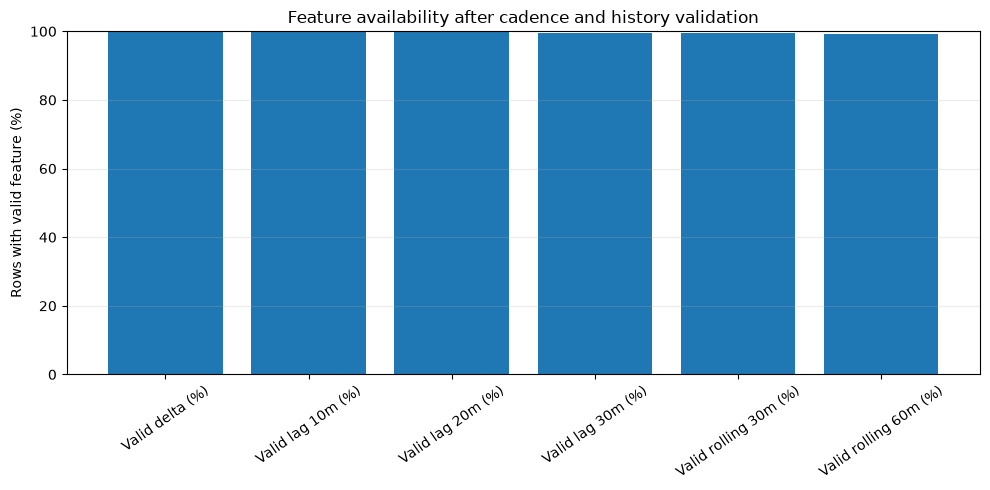

In [8]:
validity_plot = availability_table[availability_table['feature'].str.contains('Valid')].copy()
validity_plot['value'] = pd.to_numeric(validity_plot['value'], errors='coerce')
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(validity_plot['feature'], validity_plot['value'])
ax.set_title('Feature availability after cadence and history validation')
ax.set_ylabel('Rows with valid feature (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

## Delta and activity-proxy diagnostics

Raw signed deltas and absolute activity proxies are not automatically winsorized or removed. Large changes may represent rebalancing, servicing, transport, a highly active station, or real net movement. The diagnostic table is computed on the full valid feature population; the plots use only a p01–p99 visual scale so extreme values do not flatten the central distribution.

In [9]:
delta_diagnostics = run_feature_query('''
    SELECT 'delta_bikes' AS metric,
           MIN(CAST(delta_bikes AS DOUBLE)) AS min,
           approx_percentile(CAST(delta_bikes AS DOUBLE), 0.01) AS p01,
           approx_percentile(CAST(delta_bikes AS DOUBLE), 0.05) AS p05,
           approx_percentile(CAST(delta_bikes AS DOUBLE), 0.50) AS median,
           approx_percentile(CAST(delta_bikes AS DOUBLE), 0.95) AS p95,
           approx_percentile(CAST(delta_bikes AS DOUBLE), 0.99) AS p99,
           MAX(CAST(delta_bikes AS DOUBLE)) AS max,
           AVG(CAST(delta_bikes AS DOUBLE)) AS mean
    FROM final_features
    WHERE delta_bikes IS NOT NULL
    UNION ALL
    SELECT 'activity_proxy' AS metric,
           MIN(CAST(activity_proxy AS DOUBLE)) AS min,
           approx_percentile(CAST(activity_proxy AS DOUBLE), 0.01) AS p01,
           approx_percentile(CAST(activity_proxy AS DOUBLE), 0.05) AS p05,
           approx_percentile(CAST(activity_proxy AS DOUBLE), 0.50) AS median,
           approx_percentile(CAST(activity_proxy AS DOUBLE), 0.95) AS p95,
           approx_percentile(CAST(activity_proxy AS DOUBLE), 0.99) AS p99,
           MAX(CAST(activity_proxy AS DOUBLE)) AS max,
           AVG(CAST(activity_proxy AS DOUBLE)) AS mean
    FROM final_features
    WHERE activity_proxy IS NOT NULL
''')
for column in ['min', 'p01', 'p05', 'median', 'p95', 'p99', 'max', 'mean']:
    delta_diagnostics[column] = pd.to_numeric(delta_diagnostics[column], errors='coerce')
display(delta_diagnostics)

,metric,min,p01,p05,median,p95,p99,max,mean
0,delta_bikes,-24.0,-2.0,-1.0,0.0,1.000000,2.000000,25.0,-0.000100
1,activity_proxy,0.0,0.0,0.0,0.0,1.031194,2.566536,25.0,0.219368


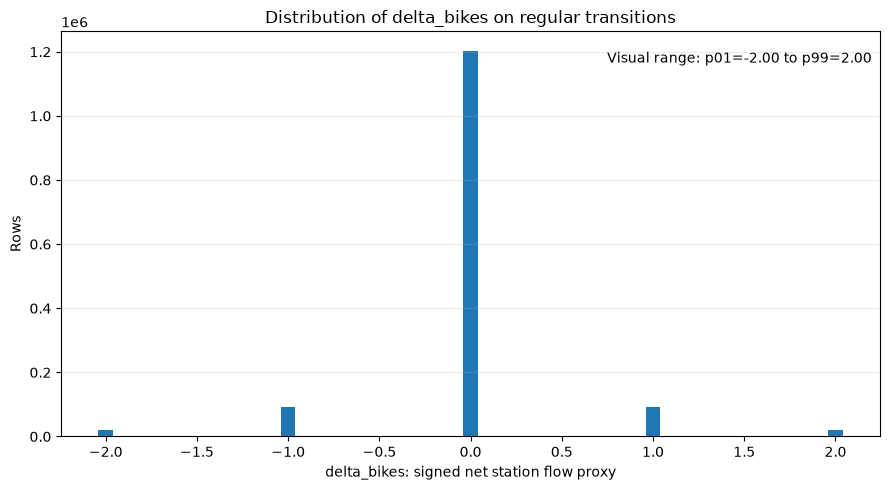

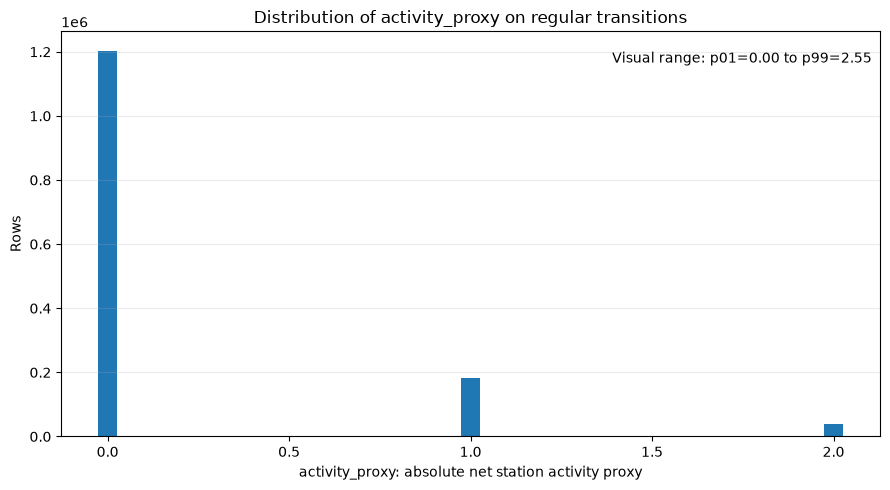

In [12]:
def binned_distribution(feature_name):
    allowed = {'delta_bikes': 'delta_bikes', 'activity_proxy': 'activity_proxy'}
    if feature_name not in allowed:
        raise ValueError(f'Unsupported distribution feature: {feature_name}')
    expression = allowed[feature_name]
    trailing_ctes = f''',
    distribution_values AS (
        SELECT CAST({expression} AS DOUBLE) AS value
        FROM final_features
        WHERE {expression} IS NOT NULL
    ),
    distribution_bounds AS (
        SELECT approx_percentile(value, 0.01) AS p01,
               approx_percentile(value, 0.99) AS p99
        FROM distribution_values
    ),
    distribution_bins AS (
        SELECT CASE
                   WHEN p99 <= p01 THEN 1
                   ELSE LEAST(50, GREATEST(1, width_bucket(value, p01, p99, 50)))
               END AS bin,
               value, p01, p99
        FROM distribution_values
        CROSS JOIN distribution_bounds
        WHERE value BETWEEN p01 AND p99
    )
'''
    return run_feature_query('''
        SELECT bin, MIN(value) AS bin_min, MAX(value) AS bin_max,
               COUNT(*) AS row_count, MIN(p01) AS p01, MAX(p99) AS p99
        FROM distribution_bins
        GROUP BY bin
        ORDER BY bin
    ''', trailing_ctes=trailing_ctes)

def plot_binned_distribution(frame, title, xlabel):
    if frame.empty:
        print(f'Skipping {title}: no valid rows.')
        return
    for column in ['bin_min', 'bin_max', 'row_count', 'p01', 'p99']:
        frame[column] = pd.to_numeric(frame[column], errors='coerce')
    centers = (frame['bin_min'] + frame['bin_max']) / 2.0
    span = frame['p99'].iloc[0] - frame['p01'].iloc[0]
    width = span / 50.0 if span > 0 else 1.0
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(centers, frame['row_count'], width=width, align='center')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Rows')
    ax.text(0.99, 0.95, f'Visual range: p01={frame["p01"].iloc[0]:.2f} to p99={frame["p99"].iloc[0]:.2f}', transform=ax.transAxes, ha='right', va='top')
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    plt.show()

delta_histogram = binned_distribution('delta_bikes')
activity_histogram = binned_distribution('activity_proxy')
plot_binned_distribution(delta_histogram, 'Distribution of delta_bikes on regular transitions', 'delta_bikes: signed net station flow proxy')
plot_binned_distribution(activity_histogram, 'Distribution of activity_proxy on regular transitions', 'activity_proxy: absolute net station activity proxy')

## Flow and activity heatmaps

These are proxy-based flow visualizations, not ride counts. The current dataset is short, so weekday patterns are preliminary and should not be presented as stable seasonal demand patterns.

local_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
1,0.112233,0.105899,0.056611,0.041766,0.035827,0.110253,0.184086,0.262272,0.241291,0.184877,...,0.283195,0.368411,0.454419,0.375545,0.388625,0.324614,0.294887,0.249108,0.200159,0.154380
2,0.079271,0.103448,0.042212,0.033888,0.033690,0.117321,0.199960,0.296274,0.296472,0.214739,...,0.336694,0.452748,0.482602,0.428826,0.380388,0.363385,0.366153,0.261368,0.192171,0.124951
3,0.084223,0.101423,0.044682,0.035213,0.037599,0.122024,0.203472,0.301091,0.296329,0.213790,...,0.294742,0.384722,0.422817,0.393452,0.379067,0.358631,0.337996,0.267758,0.222024,0.201290
4,0.094345,0.068254,0.052579,0.033333,0.032937,0.111806,0.186210,0.239087,0.206250,0.190575,...,0.338671,0.431338,0.468602,0.442437,0.406003,0.399388,0.367595,0.309637,0.245458,0.164001
5,0.106240,0.085900,0.043345,0.038310,0.038606,0.113250,0.163902,0.235190,0.250000,0.224921,...,0.363350,0.426320,0.439913,0.419129,0.396080,0.393420,0.352541,0.296198,0.242783,0.193870
6,0.159700,0.104734,0.066371,0.053452,0.019231,0.033826,0.038856,0.054635,0.080079,0.120414,...,0.257047,0.267297,0.297950,0.296274,0.324069,0.324463,0.310664,0.279531,0.207002,0.193787
7,0.138757,0.099310,0.069724,0.041420,0.038757,0.042998,0.041223,0.053353,0.084911,0.135897,...,0.274162,0.279093,0.299014,0.295978,0.329963,0.288757,0.283235,0.231065,0.169739,0.132959


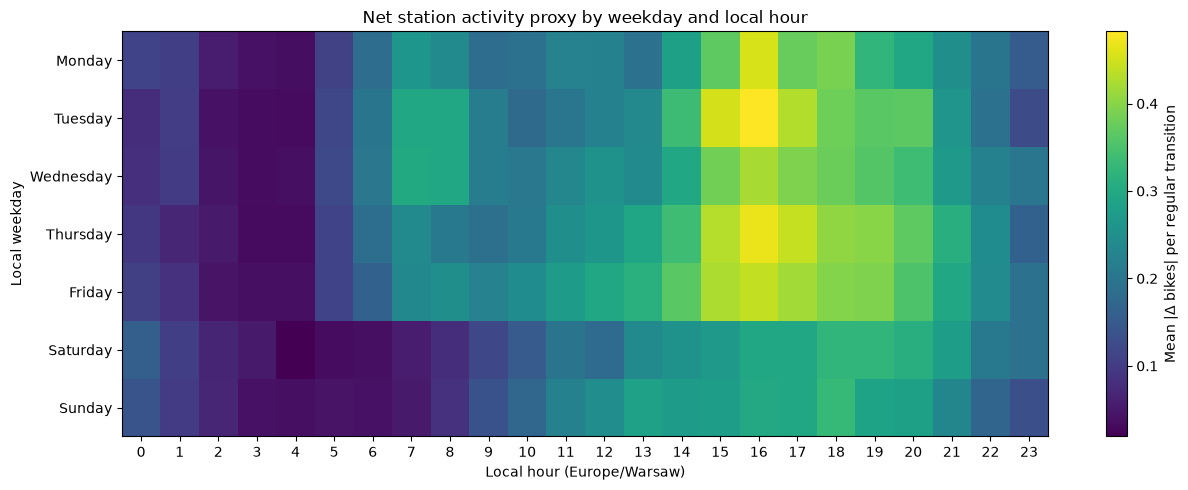

In [13]:
activity_weekday_hour = run_feature_query('''
    SELECT day_of_week, local_hour,
           AVG(CAST(activity_proxy AS DOUBLE)) AS mean_activity_proxy,
           COUNT(*) AS transition_count
    FROM final_features
    WHERE activity_proxy IS NOT NULL
    GROUP BY day_of_week, local_hour
    ORDER BY day_of_week, local_hour
''')
activity_weekday_hour['day_of_week'] = pd.to_numeric(activity_weekday_hour['day_of_week']).astype(int)
activity_weekday_hour['local_hour'] = pd.to_numeric(activity_weekday_hour['local_hour']).astype(int)
activity_weekday_hour['mean_activity_proxy'] = pd.to_numeric(activity_weekday_hour['mean_activity_proxy'], errors='coerce')
activity_heatmap = activity_weekday_hour.pivot(index='day_of_week', columns='local_hour', values='mean_activity_proxy').reindex(index=range(1, 8), columns=range(24))
display(activity_heatmap)

fig, ax = plt.subplots(figsize=(13, 5))
image = ax.imshow(activity_heatmap.to_numpy(dtype=float), aspect='auto', origin='upper', interpolation='nearest')
ax.set_title('Net station activity proxy by weekday and local hour')
ax.set_xlabel('Local hour (Europe/Warsaw)')
ax.set_ylabel('Local weekday')
ax.set_xticks(range(24), range(24))
ax.set_yticks(range(7), WEEKDAY_LABELS)
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label('Mean |Δ bikes| per regular transition')
fig.tight_layout()
plt.show()

local_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
1,0.040578,0.061956,0.007918,0.004553,0.000990,-0.026722,-0.023753,-0.008116,0.007720,0.003563,...,-0.018034,-0.035474,-0.023979,-0.000595,0.002180,0.007531,0.002378,0.026754,0.010305,0.033096
2,0.020610,0.057471,0.005747,0.004162,-0.002378,-0.024178,-0.024376,-0.023979,0.007134,0.007528,...,-0.038553,-0.052590,-0.016805,0.024318,-0.000395,0.004350,0.044286,0.032424,0.012258,0.012258
3,0.005536,0.051997,0.006327,0.011896,-0.003869,-0.025992,-0.026488,-0.017361,0.008234,-0.001091,...,-0.018750,-0.023214,-0.018651,-0.012897,-0.012004,-0.009425,0.032044,0.030456,0.020635,0.061607
4,0.009226,0.014087,0.009325,0.005357,-0.003373,-0.022520,-0.024306,-0.009325,0.005258,0.000099,...,-0.038553,-0.040111,-0.025079,0.008393,-0.003160,-0.000099,0.046900,0.047986,0.027646,0.016291
5,0.014613,0.032385,0.008195,0.013823,-0.004246,-0.029325,-0.021524,-0.018957,0.000197,-0.007899,...,-0.022069,-0.046296,-0.020292,-0.008373,0.000493,-0.005713,0.015268,0.019996,0.026407,0.015868
6,0.027800,0.029191,0.009172,0.023471,-0.003057,-0.000690,-0.004339,-0.002367,-0.007101,-0.014892,...,-0.018135,0.006702,-0.016854,-0.016558,-0.008476,0.005322,0.011827,0.024354,0.022189,0.019822
7,0.021006,0.033826,0.020020,0.002367,-0.004832,-0.008087,-0.002564,0.000296,-0.007988,-0.008481,...,0.002761,-0.000592,-0.016174,-0.013336,-0.000645,0.005917,0.038659,0.021598,0.015377,0.014686


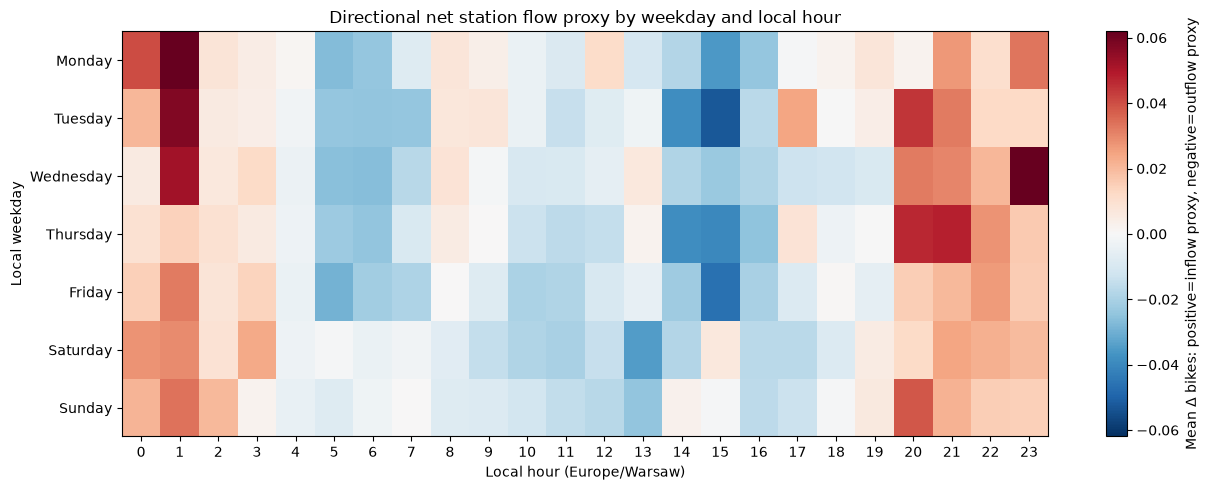

In [14]:
directional_weekday_hour = run_feature_query('''
    SELECT day_of_week, local_hour,
           AVG(CAST(delta_bikes AS DOUBLE)) AS mean_delta_bikes,
           COUNT(*) AS transition_count
    FROM final_features
    WHERE delta_bikes IS NOT NULL
    GROUP BY day_of_week, local_hour
    ORDER BY day_of_week, local_hour
''')
directional_weekday_hour['day_of_week'] = pd.to_numeric(directional_weekday_hour['day_of_week']).astype(int)
directional_weekday_hour['local_hour'] = pd.to_numeric(directional_weekday_hour['local_hour'], errors='coerce').astype(int)
directional_weekday_hour['mean_delta_bikes'] = pd.to_numeric(directional_weekday_hour['mean_delta_bikes'], errors='coerce')
directional_heatmap = directional_weekday_hour.pivot(index='day_of_week', columns='local_hour', values='mean_delta_bikes').reindex(index=range(1, 8), columns=range(24))
display(directional_heatmap)

values = directional_heatmap.to_numpy(dtype=float)
finite_values = values[np.isfinite(values)]
if finite_values.size and finite_values.min() < 0 < finite_values.max():
    limit = max(abs(finite_values.min()), abs(finite_values.max()))
    directional_norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
else:
    limit = max(abs(finite_values).max(), 1.0) if finite_values.size else 1.0
    directional_norm = Normalize(vmin=-limit, vmax=limit)

fig, ax = plt.subplots(figsize=(13, 5))
image = ax.imshow(values, aspect='auto', origin='upper', interpolation='nearest', cmap='RdBu_r', norm=directional_norm)
ax.set_title('Directional net station flow proxy by weekday and local hour')
ax.set_xlabel('Local hour (Europe/Warsaw)')
ax.set_ylabel('Local weekday')
ax.set_xticks(range(24), range(24))
ax.set_yticks(range(7), WEEKDAY_LABELS)
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label('Mean Δ bikes: positive=inflow proxy, negative=outflow proxy')
fig.tight_layout()
plt.show()

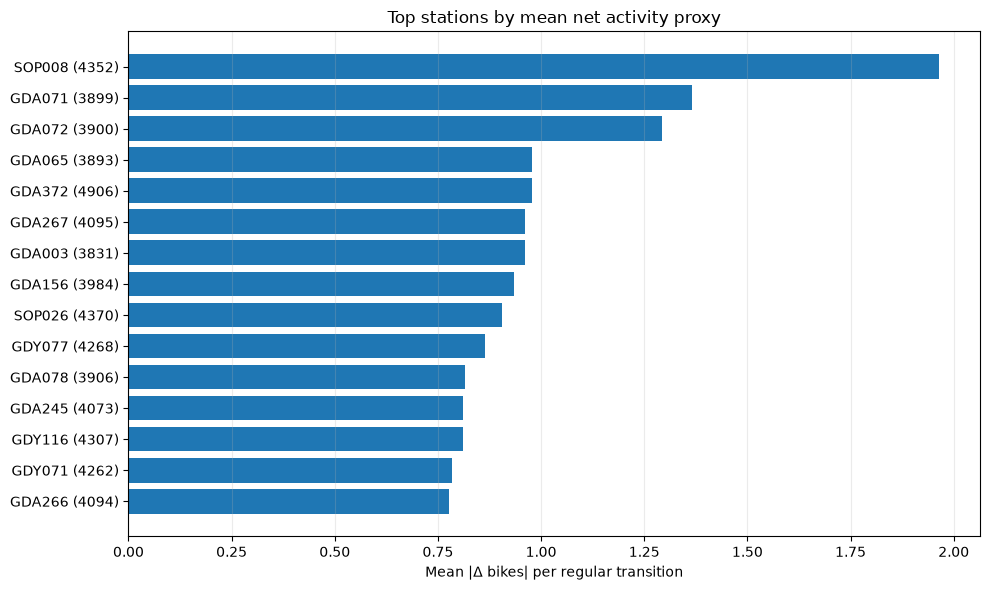

local_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
station_label,,,,,,,,,,,,,,,,,,,,,
SOP008 (4352),2.272727,1.121212,0.484848,0.371429,0.236111,0.166667,0.208333,0.722222,1.986111,1.458333,...,2.569444,2.736111,3.416667,2.774648,3.070423,3.666667,3.138889,2.958333,2.027778,1.277778
GDA071 (3899),1.075758,0.818182,0.590909,0.357143,0.138889,0.277778,0.152778,0.291667,0.444444,0.819444,...,2.333333,1.666667,2.236111,2.169014,2.704225,3.347222,2.361111,1.930556,1.680556,0.986111
GDA072 (3900),0.590909,0.575758,0.500000,0.342857,0.097222,0.222222,0.194444,0.152778,0.486111,1.055556,...,2.222222,2.152778,2.291667,1.901408,2.845070,2.847222,2.319444,1.666667,1.083333,0.833333
GDA065 (3893),0.151515,0.121212,0.060606,0.028571,0.013889,0.194444,0.486111,2.555556,3.458333,1.222222,...,1.236111,2.763889,3.416667,1.042254,0.704225,0.597222,0.472222,0.583333,0.361111,0.305556
GDA372 (4906),1.287879,0.424242,0.348485,0.214286,0.208333,0.569444,0.194444,0.194444,0.319444,0.430556,...,1.194444,1.597222,2.069444,1.535211,1.901408,1.708333,2.027778,1.486111,1.652778,1.055556
GDA003 (3831),0.409091,0.560606,0.363636,0.142857,0.097222,0.069444,0.291667,0.180556,0.305556,0.569444,...,1.486111,1.458333,1.638889,1.366197,1.535211,1.972222,1.958333,1.347222,1.458333,1.069444
GDA267 (4095),0.272727,0.409091,0.136364,0.100000,0.208333,0.388889,0.458333,0.291667,0.625000,0.763889,...,1.777778,1.972222,1.833333,1.661972,1.971831,1.513889,1.111111,0.930556,0.652778,0.430556
GDA156 (3984),0.378788,0.227273,0.075758,0.114286,0.055556,0.208333,0.430556,0.638889,1.111111,0.694444,...,1.291667,1.652778,2.166667,1.478873,1.929577,1.513889,1.625000,1.097222,0.305556,0.458333
SOP026 (4370),0.287879,0.075758,0.151515,0.042857,0.041667,0.152778,0.291667,0.513889,1.347222,0.750000,...,1.291667,1.722222,1.500000,1.718310,1.957746,1.750000,1.486111,1.027778,0.708333,0.611111


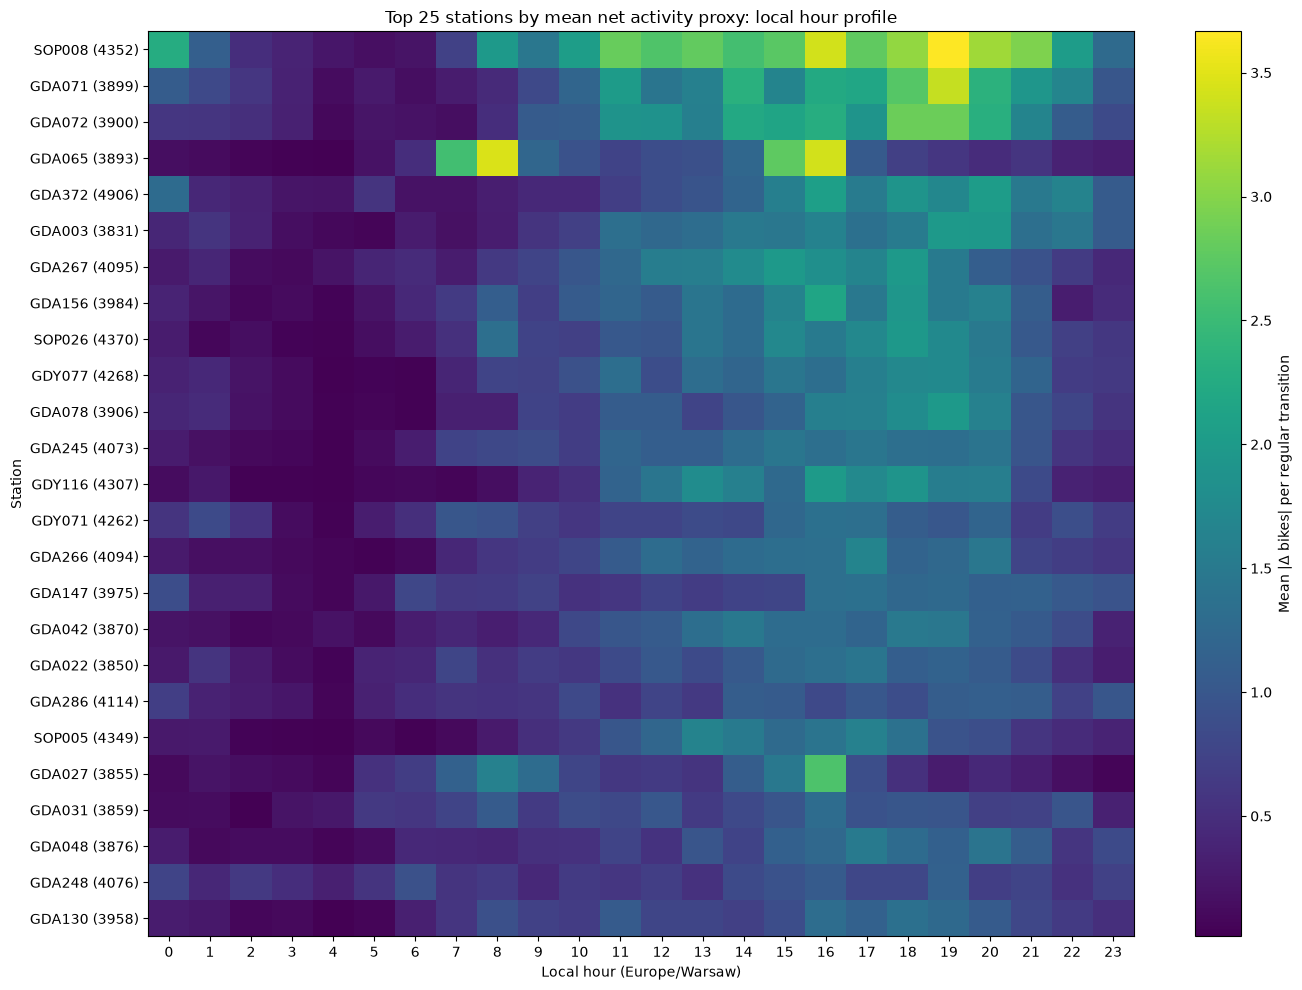

In [15]:
top_station_cte = ''',
top_active_stations AS (
    SELECT station_id, AVG(CAST(activity_proxy AS DOUBLE)) AS station_mean_activity_proxy
    FROM final_features
    WHERE activity_proxy IS NOT NULL
    GROUP BY station_id
    ORDER BY station_mean_activity_proxy DESC
    LIMIT 25
)
'''
top_station_hour = run_feature_query('''
    SELECT f.station_id, f.station_name, f.local_hour,
           t.station_mean_activity_proxy,
           AVG(CAST(f.activity_proxy AS DOUBLE)) AS mean_activity_proxy
    FROM final_features f
    JOIN top_active_stations t ON f.station_id = t.station_id
    WHERE f.activity_proxy IS NOT NULL
    GROUP BY f.station_id, f.station_name, f.local_hour, t.station_mean_activity_proxy
    ORDER BY t.station_mean_activity_proxy DESC, f.station_id, f.local_hour
''', trailing_ctes=top_station_cte)

if top_station_hour.empty:
    print('No valid station activity rows are available for the top-station heatmap.')
else:
    top_station_hour['local_hour'] = pd.to_numeric(top_station_hour['local_hour']).astype(int)
    top_station_hour['mean_activity_proxy'] = pd.to_numeric(top_station_hour['mean_activity_proxy'], errors='coerce')
    top_station_hour['station_mean_activity_proxy'] = pd.to_numeric(top_station_hour['station_mean_activity_proxy'], errors='coerce')
    top_station_hour['station_label'] = top_station_hour['station_name'].fillna(top_station_hour['station_id']).astype(str) + ' (' + top_station_hour['station_id'].astype(str) + ')'
    station_order = top_station_hour.drop_duplicates('station_id').sort_values('station_mean_activity_proxy', ascending=False)['station_label'].tolist()
    top_station_bar = top_station_hour.drop_duplicates('station_id').nlargest(15, 'station_mean_activity_proxy').sort_values('station_mean_activity_proxy')
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_station_bar['station_label'], top_station_bar['station_mean_activity_proxy'])
    ax.set_title('Top stations by mean net activity proxy')
    ax.set_xlabel('Mean |Δ bikes| per regular transition')
    ax.grid(axis='x', alpha=0.25)
    fig.tight_layout()
    plt.show()
    top_station_heatmap = top_station_hour.pivot(index='station_label', columns='local_hour', values='mean_activity_proxy').reindex(index=station_order, columns=range(24))
    display(top_station_heatmap)
    fig, ax = plt.subplots(figsize=(14, 10))
    image = ax.imshow(top_station_heatmap.to_numpy(dtype=float), aspect='auto', origin='upper', interpolation='nearest')
    ax.set_title('Top 25 stations by mean net activity proxy: local hour profile')
    ax.set_xlabel('Local hour (Europe/Warsaw)')
    ax.set_ylabel('Station')
    ax.set_xticks(range(24), range(24))
    ax.set_yticks(range(len(station_order)), station_order)
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label('Mean |Δ bikes| per regular transition')
    fig.tight_layout()
    plt.show()

## Hourly flow profile

This profile shows the shape of the observed net flow proxies during the local day. It must not yet be labelled as true rush-hour demand because the snapshot difference cannot recover offsetting trips and can include operator activity.

,local_hour,mean_net_inflow_proxy,mean_net_outflow_proxy,mean_activity_proxy
0,0,0.067568,0.048286,0.115853
1,1,0.064445,0.028952,0.093397
2,2,0.032780,0.022464,0.055244
3,3,0.025122,0.014951,0.040073
4,4,0.015149,0.018495,0.033643
5,5,0.035440,0.054099,0.089539
6,6,0.060133,0.077325,0.137458
7,7,0.091468,0.102084,0.193552
8,8,0.099281,0.098292,0.197574
9,9,0.088185,0.092652,0.180837


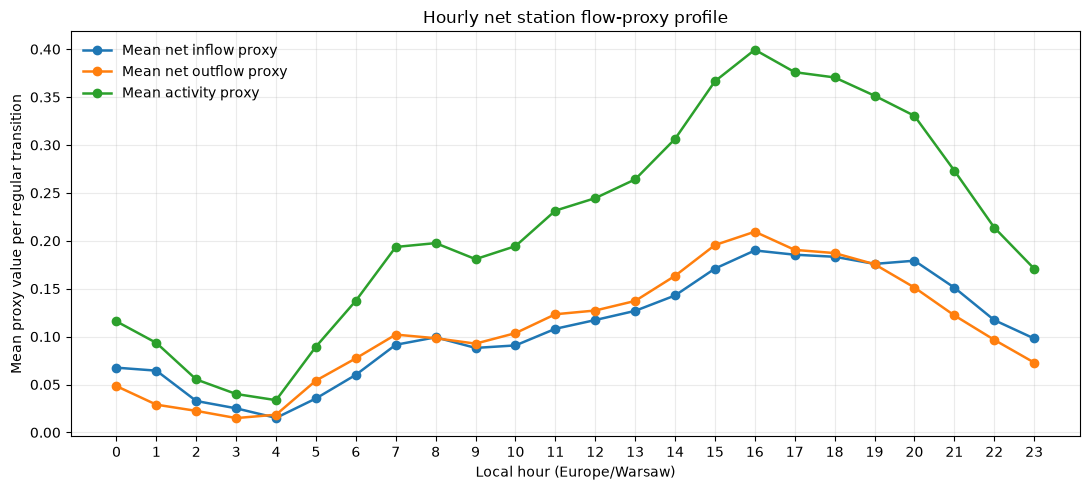

In [16]:
hourly_flow_profile = run_feature_query('''
    SELECT local_hour,
           AVG(CAST(net_inflow_proxy AS DOUBLE)) AS mean_net_inflow_proxy,
           AVG(CAST(net_outflow_proxy AS DOUBLE)) AS mean_net_outflow_proxy,
           AVG(CAST(activity_proxy AS DOUBLE)) AS mean_activity_proxy
    FROM final_features
    WHERE activity_proxy IS NOT NULL
    GROUP BY local_hour
    ORDER BY local_hour
''')
hourly_flow_profile['local_hour'] = pd.to_numeric(hourly_flow_profile['local_hour']).astype(int)
for column in ['mean_net_inflow_proxy', 'mean_net_outflow_proxy', 'mean_activity_proxy']:
    hourly_flow_profile[column] = pd.to_numeric(hourly_flow_profile[column], errors='coerce')
display(hourly_flow_profile)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hourly_flow_profile['local_hour'], hourly_flow_profile['mean_net_inflow_proxy'], marker='o', linewidth=1.8, label='Mean net inflow proxy')
ax.plot(hourly_flow_profile['local_hour'], hourly_flow_profile['mean_net_outflow_proxy'], marker='o', linewidth=1.8, label='Mean net outflow proxy')
ax.plot(hourly_flow_profile['local_hour'], hourly_flow_profile['mean_activity_proxy'], marker='o', linewidth=1.8, label='Mean activity proxy')
ax.set_title('Hourly net station flow-proxy profile')
ax.set_xlabel('Local hour (Europe/Warsaw)')
ax.set_ylabel('Mean proxy value per regular transition')
ax.set_xticks(range(24))
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Station examples and NULL analysis

The next query is a small sanity check: it prefers SOP008 when present, then includes the highest-activity stations, and returns at most 20 recent regular observations per selected station. This is not a full station-history download.

Warm-up NULLs are expected for the first observations of a station. A separate invalid-cadence count identifies NULLs caused by a non-regular timestamp gap.

In [27]:
station_examples_cte = ''',
station_activity_rank AS (
    SELECT station_id, station_name, AVG(CAST(activity_proxy AS DOUBLE)) AS mean_activity_proxy
    FROM final_features
    WHERE activity_proxy IS NOT NULL
    GROUP BY station_id, station_name
    ORDER BY CASE WHEN station_name = 'SOP008' THEN 0 ELSE 1 END, mean_activity_proxy DESC
    LIMIT 3
),
station_example_ranked AS (
    SELECT f.snapshot_ts, f.station_id, f.station_name,
           f.bikes_available, f.prev_bikes, f.delta_bikes,
           f.activity_proxy, f.bikes_lag_10m,
           f.rolling_bikes_mean_30m,
           ROW_NUMBER() OVER (PARTITION BY f.station_id ORDER BY f.snapshot_ts DESC) AS example_rank
    FROM final_features f
    JOIN station_activity_rank s ON f.station_id = s.station_id
    WHERE f.is_regular_transition
)
'''
station_examples = run_feature_query('''
    SELECT snapshot_ts, station_id, station_name, bikes_available, prev_bikes,
           delta_bikes, activity_proxy, bikes_lag_10m, rolling_bikes_mean_30m
    FROM station_example_ranked
    WHERE example_rank <= 20
    ORDER BY station_id, snapshot_ts DESC
''', trailing_ctes=station_examples_cte)
display(station_examples)
print(f'Sanity-check rows returned: {len(station_examples):,}')

,snapshot_ts,station_id,station_name,bikes_available,prev_bikes,delta_bikes,activity_proxy,bikes_lag_10m,rolling_bikes_mean_30m
0,2026-08-23 21:58:08.250,3899,GDA071,8,8,0,0,8,8.00
1,2026-08-23 21:48:08.400,3899,GDA071,8,8,0,0,8,8.00
2,2026-08-23 21:38:08.213,3899,GDA071,8,8,0,0,8,8.00
3,2026-08-23 21:28:08.343,3899,GDA071,8,8,0,0,8,8.00
4,2026-08-23 21:18:08.218,3899,GDA071,8,8,0,0,8,8.00
5,2026-08-23 21:08:08.388,3899,GDA071,8,8,0,0,8,8.00
6,2026-08-23 20:58:08.335,3899,GDA071,8,8,0,0,8,8.25
7,2026-08-23 20:48:08.350,3899,GDA071,8,8,0,0,8,8.50
8,2026-08-23 20:38:08.316,3899,GDA071,8,9,-1,1,9,9.25
9,2026-08-23 20:28:08.362,3899,GDA071,9,9,0,0,9,10.75


Sanity-check rows returned: 60


In [18]:
null_analysis = run_feature_query('''
    SELECT 'delta' AS feature_group, 'delta_bikes' AS feature,
           COUNT(*) AS total_rows,
           SUM(CASE WHEN delta_bikes IS NULL THEN 1 ELSE 0 END) AS null_rows,
           SUM(CASE WHEN delta_bikes IS NULL AND prev_snapshot_ts IS NULL THEN 1 ELSE 0 END) AS expected_warmup_rows,
           SUM(CASE WHEN delta_bikes IS NULL AND prev_snapshot_ts IS NOT NULL AND NOT is_regular_transition THEN 1 ELSE 0 END) AS invalid_cadence_rows
    FROM final_features
    UNION ALL
    SELECT 'lag', 'bikes_lag_10m', COUNT(*),
           SUM(CASE WHEN bikes_lag_10m IS NULL THEN 1 ELSE 0 END),
           SUM(CASE WHEN bikes_lag_10m_timestamp IS NULL THEN 1 ELSE 0 END),
           SUM(CASE WHEN bikes_lag_10m_timestamp IS NOT NULL AND NOT has_valid_lag_10m THEN 1 ELSE 0 END)
    FROM final_features
    UNION ALL
    SELECT 'lag', 'bikes_lag_20m', COUNT(*),
           SUM(CASE WHEN bikes_lag_20m IS NULL THEN 1 ELSE 0 END),
           SUM(CASE WHEN bikes_lag_20m_timestamp IS NULL THEN 1 ELSE 0 END),
           SUM(CASE WHEN bikes_lag_20m_timestamp IS NOT NULL AND NOT has_valid_lag_20m THEN 1 ELSE 0 END)
    FROM final_features
    UNION ALL
    SELECT 'lag', 'bikes_lag_30m', COUNT(*),
           SUM(CASE WHEN bikes_lag_30m IS NULL THEN 1 ELSE 0 END),
           SUM(CASE WHEN bikes_lag_30m_timestamp IS NULL THEN 1 ELSE 0 END),
           SUM(CASE WHEN bikes_lag_30m_timestamp IS NOT NULL AND NOT has_valid_lag_30m THEN 1 ELSE 0 END)
    FROM final_features
    UNION ALL
    SELECT 'rolling', 'rolling_30m', COUNT(*),
           SUM(CASE WHEN rolling_bikes_mean_30m IS NULL THEN 1 ELSE 0 END),
           SUM(CASE WHEN rolling_30m_start_ts IS NULL THEN 1 ELSE 0 END),
           SUM(CASE WHEN rolling_30m_start_ts IS NOT NULL AND NOT has_valid_rolling_30m THEN 1 ELSE 0 END)
    FROM final_features
    UNION ALL
    SELECT 'rolling', 'rolling_60m', COUNT(*),
           SUM(CASE WHEN rolling_bikes_mean_60m IS NULL THEN 1 ELSE 0 END),
           SUM(CASE WHEN rolling_60m_start_ts IS NULL THEN 1 ELSE 0 END),
           SUM(CASE WHEN rolling_60m_start_ts IS NOT NULL AND NOT has_valid_rolling_60m THEN 1 ELSE 0 END)
    FROM final_features
''')
for column in ['total_rows', 'null_rows', 'expected_warmup_rows', 'invalid_cadence_rows']:
    null_analysis[column] = pd.to_numeric(null_analysis[column], errors='coerce')
null_analysis['null_rate_pct'] = 100.0 * null_analysis['null_rows'] / null_analysis['total_rows'].replace(0, np.nan)
display(null_analysis)

,feature_group,feature,total_rows,null_rows,expected_warmup_rows,invalid_cadence_rows,null_rate_pct
0,delta,delta_bikes,1441042,2535,852,1683,0.175914
1,lag,bikes_lag_20m,1441042,4233,1704,2529,0.293746
2,lag,bikes_lag_30m,1441042,5931,2556,3375,0.411577
3,rolling,rolling_60m,1441042,11022,5112,5910,0.764863
4,lag,bikes_lag_10m,1441042,2535,852,1683,0.175914
5,rolling,rolling_30m,1441042,5931,2556,3375,0.411577


## Leakage safety

- Temporal features use only the timestamp at t.
- Current-state features use the station state available at t.
- Lag features use only validated observations at t−n and retain their actual lag timestamps.
- Rolling windows use `ROWS BETWEEN ... PRECEDING AND CURRENT ROW`; no future rows are included.
- Flow proxies use t and t−1 only, and only for a regular transition.
- No feature uses t+n.
- A future ML target will be defined separately after weather enrichment and further review.
- `latest_station_dimension` is acceptable for this short notebook, but production ML must verify a temporal/as-of dimension join if capacity, coordinates, or other station attributes can change historically.

The static self-review below checks the implemented SQL for the main leakage and write-safety invariants.

In [19]:
feature_sql_upper = FEATURE_CTES_SQL.upper()
forbidden_write_phrases = ['INSERT INTO', 'CREATE TABLE', 'CREATE VIEW', 'UNLOAD', 'WR.S3.TO_PARQUET']
assert not any(phrase in feature_sql_upper for phrase in forbidden_write_phrases)
assert 'FOLLOWING' not in feature_sql_upper
assert 'CURRENT ROW' in feature_sql_upper
assert 'LAG(' in feature_sql_upper
assert 'AT_TIMEZONE(WITH_TIMEZONE(SNAPSHOT_TS' in feature_sql_upper
assert 'ADDRESS' not in feature_sql_upper
assert 'CROSS_STREET' not in feature_sql_upper
assert 'BIKES_AVAILABLE_T_PLUS' not in feature_sql_upper

leakage_review = pd.DataFrame([
    {'check': 'Future window', 'status': 'PASS', 'evidence': 'No FOLLOWING frame; windows end at CURRENT ROW.'},
    {'check': 'Lag direction', 'status': 'PASS', 'evidence': 'LAG is partitioned by station_id and ordered by snapshot_ts.'},
    {'check': 'Flow direction', 'status': 'PASS', 'evidence': 'Deltas use current state minus previous state and regular cadence only.'},
    {'check': 'Timezone', 'status': 'PASS', 'evidence': 'UTC snapshot_ts is converted with Europe/Warsaw ZoneInfo semantics in Athena.'},
    {'check': 'Static dimension join', 'status': 'CONDITIONAL', 'evidence': 'Latest ROW_NUMBER dimension is acceptable for this short notebook; production must review temporal/as-of validity if station attributes change.'},
    {'check': 'AWS writes', 'status': 'PASS', 'evidence': 'Notebook uses SELECT-only queries and no data-publishing operation.'},
])
display(leakage_review)
print('Static leakage and read-only review passed.')

,check,status,evidence
0,Future window,PASS,No FOLLOWING frame; windows end at CURRENT ROW.
1,Lag direction,PASS,LAG is partitioned by station_id and ordered b...
2,Flow direction,PASS,Deltas use current state minus previous state ...
3,Timezone,PASS,UTC snapshot_ts is converted with Europe/Warsa...
4,Static dimension join,CONDITIONAL,Latest ROW_NUMBER dimension is acceptable for ...
5,AWS writes,PASS,Notebook uses SELECT-only queries and no data-...


Static leakage and read-only review passed.


## Key Feature Engineering findings

The following cell generates concise portfolio-quality findings from the already computed analysis DataFrames. It runs no additional Athena query.

In [28]:
def _finding_value(frame, label, value_column='value'):
    rows = frame.loc[frame['feature'].eq(label), value_column]
    return rows.iloc[0] if not rows.empty else None

def _finding_number(value, decimals=2):
    if value is None or pd.isna(value):
        return 'n/a'
    return f'{float(value):,.{decimals}f}'

valid_delta_pct = _finding_value(availability_table, 'Valid delta (%)')
valid_lag10_pct = _finding_value(availability_table, 'Valid lag 10m (%)')
valid_lag20_pct = _finding_value(availability_table, 'Val id lag 20m (%)')
valid_lag30_pct = _finding_value(availability_table, 'Valid lag 30m (%)')
valid_rolling30_pct = _finding_value(availability_table, 'Valid rolling 30m (%)')
valid_rolling60_pct = _finding_value(availability_table, 'Valid rolling 60m (%)')

delta_row = delta_diagnostics.loc[delta_diagnostics['metric'].eq('delta_bikes')]
if delta_row.empty:
    delta_summary = 'unavailable'
else:
    delta_row = delta_row.iloc[0]
    delta_summary = (
        f"median={_finding_number(delta_row['median'])}, "
        f"p01={_finding_number(delta_row['p01'])}, "
        f"p99={_finding_number(delta_row['p99'])}, "
        f"min={_finding_number(delta_row['min'])}, "
        f"max={_finding_number(delta_row['max'])}"
    )

hourly_activity = hourly_flow_profile.dropna(subset=['mean_activity_proxy']).copy()
if hourly_activity.empty:
    strongest_hour_text = 'unavailable'
else:
    strongest_hour = hourly_activity.loc[hourly_activity['mean_activity_proxy'].idxmax()]
    strongest_hour_text = (
        f"{int(strongest_hour['local_hour']):02d}:00 "
        f"({_finding_number(strongest_hour['mean_activity_proxy'])} mean activity_proxy)"
    )

if 'top_station_hour' not in globals() or top_station_hour.empty:
    most_active_station_text = 'unavailable'
else:
    station_activity = top_station_hour[['station_id', 'station_name', 'station_mean_activity_proxy']].drop_duplicates('station_id').copy()
    station_activity['station_mean_activity_proxy'] = pd.to_numeric(station_activity['station_mean_activity_proxy'], errors='coerce')
    station_activity = station_activity.dropna(subset=['station_mean_activity_proxy']).sort_values('station_mean_activity_proxy', ascending=False)
    if station_activity.empty:
        most_active_station_text = 'unavailable'
    else:
        most_active_station = station_activity.iloc[0]
        station_name = most_active_station['station_name']
        station_label = station_name if pd.notna(station_name) and str(station_name).strip() else most_active_station['station_id']
        most_active_station_text = f"{station_label} ({most_active_station['station_id']}): {_finding_number(most_active_station['station_mean_activity_proxy'])} mean activity_proxy"

period_days = None
if not analysis_period.empty and pd.notna(analysis_period.loc[0, 'duration']):
    period_days = analysis_period.loc[0, 'duration'].total_seconds() / 86400.0
history_text = f"approximately {period_days:.1f} days" if period_days is not None else 'the currently available history'

display(Markdown(f'''
### Key Feature Engineering findings

- **Valid transition / delta availability:** {_finding_number(valid_delta_pct)}%; valid lags: 10m **{_finding_number(valid_lag10_pct)}%**, 20m **{_finding_number(valid_lag20_pct)}%**, 30m **{_finding_number(valid_lag30_pct)}%**.
- **Valid rolling availability:** 30m **{_finding_number(valid_rolling30_pct)}%**, 60m **{_finding_number(valid_rolling60_pct)}%**.
- **Delta distribution:** {delta_summary}.
- **Strongest mean activity hour:** {strongest_hour_text}.
- **Most active station in the selected ranking:** {most_active_station_text}.
- **Interpretation:** weekday/hour patterns are preliminary because the observed history spans {history_text}.
- **Caveat:** `activity_proxy` and net station flow proxies are not ride counts or ground-truth user demand; rebalancing, service, and bike transport can also affect `delta_bikes`.
'''))


### Key Feature Engineering findings

- **Valid transition / delta availability:** 99.82%; valid lags: 10m **99.82%**, 20m **n/a%**, 30m **99.59%**.
- **Valid rolling availability:** 30m **99.59%**, 60m **99.24%**.
- **Delta distribution:** median=0.00, p01=-2.00, p99=2.00, min=-24.00, max=25.00.
- **Strongest mean activity hour:** 16:00 (0.40 mean activity_proxy).
- **Most active station in the selected ranking:** SOP008 (4352): 1.97 mean activity_proxy.
- **Interpretation:** weekday/hour patterns are preliminary because the observed history spans approximately 11.9 days.
- **Caveat:** `activity_proxy` and net station flow proxies are not ride counts or ground-truth user demand; rebalancing, service, and bike transport can also affect `delta_bikes`.


## Target selection is intentionally deferred

Candidate targets such as future bike availability at +30 minutes or +60 minutes, and empty/full risk, should be selected as a separate modelling decision after weather enrichment and further analysis. This notebook does not implement a future target, target leakage, or an empty-risk classifier.

Optional geospatial flow maps are also deferred here. The three compact flow heatmaps and hourly profile are the priority; maps can be added later if they improve the analytical story without expanding the notebook unnecessarily.

## Next step: production feature layer

After review and acceptance of these definitions, the production path is:

`Athena / transformer logic`
↓
`S3 CURATED / FEATURES Parquet`
↓
`weather enrichment`
↓
`statistical analysis`
↓
`ML forecasting`

The production write path is deliberately outside this notebook and will be implemented only after the feature contract is approved.